# Bundle Adjustment — API Demo

How to apply bundle adjustment (BA) to a feedforward pointcloud result.

**Prerequisites:** [Keyframe Extraction](../01_preprocessing/keyframe_extraction.ipynb) → [Feedforward Methods](feedforward_methods.ipynb)

**Not an evaluation.** For benchmark results across `baseline / ba / lc`, see `eval_7scenes_gt.ipynb`. Compute lives in `evals/eval_gt.py`.

The pipeline: `creator.run(<frames dir>)` → `ba.refine(result)` → `creator.reproject(refined)` → `creator.build_colmap(RECON)`. BA refines poses on the **fresh** feedforward result, whose intrinsics are at original image resolution; it re-runs inference here rather than reading the `vggt_omega.zarr` cache, which stores model-resolution geometry meant for downstream reprojection and localization.

VGGT-Omega is the backbone; other backends work identically via `make_creator(<name>)` — see the registry table in [Feedforward Methods](feedforward_methods.ipynb).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import torch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3D projection

# Static backend for headless (nbconvert) execution; interactive trame otherwise
pv.set_jupyter_backend("static" if os.environ.get("PYVISTA_OFF_SCREEN") else "trame")

from collab_splats.geometry import BundleAdjustment, BundleAdjustmentConfig
from collab_splats.pointcloud import make_creator
from collab_splats.pointcloud.feedforward import FeedforwardResult
from collab_splats.preproc import frames as fr
from collab_splats.utils.visualization import (
    CAMERA_KWARGS,
    PCD_KWARGS,
    VIZ_KWARGS,
    pointcloud_to_polydata,
    visualize_splat,
)

Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0


/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/ti

## §0 — Setup

Source the common tutorial configuration: keyframes are read from the canonical `images/` dir (`IMAGES_DIR`, written by [tutorial 01](../01_preprocessing/keyframe_extraction.ipynb) and capped at `MAX_FRAMES`), and everything this notebook writes lands under `TUTORIAL_CACHE`.

In [ ]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────

# Keyframes from the canonical images/ dir (nb 01) — the PNGs on disk are already
# what the path-based creator API wants. Capped at MAX_FRAMES.
image_paths = fr.frame_paths(IMAGES_DIR)[:MAX_FRAMES]
assert image_paths, f"no keyframes in {IMAGES_DIR} — run 01_preprocessing first"

# All notebook writes go under the tutorial cache
RECON = TUTORIAL_CACHE / "vggt_omega" / "ba"
RECON.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{len(image_paths)} keyframes from {IMAGES_DIR}  device: {device}")

## §1 — Reconstruct, Refine, Reproject, Export

Stage the `MAX_FRAMES` keyframe subset into a scratch directory (the creator API consumes a directory), then run the four-step pipeline:

- `creator.run()` runs the feedforward model and returns a `FeedforwardResult`.
- `BundleAdjustment.refine()` refines poses (returns a new `FeedforwardResult` with updated extrinsics/intrinsics).
- `creator.reproject()` re-extracts world points using the refined poses.
- `creator.build_colmap()` exports the result to COLMAP format.

In [4]:
# Stage the MAX_FRAMES keyframe subset — the creator API consumes a directory
_subset_dir = TUTORIAL_CACHE / "ba_frames"
shutil.rmtree(_subset_dir, ignore_errors=True)
_subset_dir.mkdir(parents=True)
for p in image_paths:
    (_subset_dir / p.name).symlink_to(p)

creator = make_creator("vggt_omega")
ba = BundleAdjustment(config=BundleAdjustmentConfig(capture_loss_history=True))

# Run feedforward inference; loads model + builds FeedforwardResult with raw_outputs
ff_result = creator.run(_subset_dir, device)
print(f"feedforward: {ff_result.points.shape[0]:,} points, {ff_result.extrinsics.shape[0]} cameras")

# Camera poses before BA — kept for the pre/post comparison in §2
extrinsics_pre = ff_result.extrinsics.copy()  # (N, 4, 4)

# Refine camera poses — returns new FeedforwardResult with updated extrinsics/intrinsics
refined = ba.refine(ff_result)

# Re-project world points using refined poses (requires raw_outputs from creator.run())
reprojected = creator.reproject(refined)
print(f"after BA: {reprojected.points.shape[0]:,} points")

# Export to COLMAP format
colmap_result = creator.build_colmap(RECON)
print(f"COLMAP: {len(colmap_result.points):,} points, {len(colmap_result.image_paths)} cameras")

[14:54:18] Loading model (cuda)...                                                                      ]8;id=14360567;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=14360568;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#800\800]8;;\

/workspace/collab-splats/collab_splats/pointcloud/feedforward/vggt_omega.py:181: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(ckpt_path

[14:54:52]   done in 33.3s                                                                              ]8;id=14360574;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=14360575;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#802\802]8;;\

           Preprocessing images...                                                                      ]8;id=14360581;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=14360582;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#806\806]8;;\

[14:54:55]   → 30 images  done in 3.6s                                                                  ]8;id=14360588;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=14360589;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#808\808]8;;\

...

[14:55:23] Building COLMAP reconstruction...                                                            ]8;id=14360623;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=14360624;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#828\828]8;;\

Warning: More than one camera is found in 
/workspace/outputs/tutorial_cache/2024_02_06/C0043/vggt_omega/ba/colmap/sparse/0

{1: Camera(id=1, model='PINHOLE', width=1080, height=1920, params=array([1552.05883026, 1538.99408559,  540.        ,  959.99996567])), 2: Camera(id=2, model='PINHOLE', width=1080, height=1920, params=array([1548.92875671, 1535.70789611,  540.        ,  959.99996567])), 3: Camera(id=3, model='PINHOLE', width=1080, height=1920, params=array([1551.02405548, 1538.22129537,  540.        ,  959.99996567])), 4: Camera(id=4, model='PINHOLE', width=1080, height=1920, params=array([1553.40911865, 1540.59297952,  540.        ,  959.99996567])), 5: Camera(id=5, model='PINHOLE', width=1080, height=1920, params=array([1552.74873734, 1539.71236999,  540.        ,  959.99996567])), 6: Camera(id=6, model='PINHOLE', width=1080, height=1920, params=array([1550.22720337, 1538.02047552,  540.        ,  959.99996567])), 7: Camera(id=7, model='PINHOLE', width=1080, height=1920, params=array([1552.51424789, 1538.98165145,  540.        ,  959.99996567])), 8: Camera(id=8, model='PINHOLE', width=1080, height=19

[14:55:51]   done in 28.2s                                                                              ]8;id=14360630;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=14360631;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#853\853]8;;\

COLMAP: 500,000 points, 30 cameras


## §2 — Visualizations

Pre/post BA camera positions and LM loss convergence curve.

`extrinsics_pre` and `refined.extrinsics` are both `(N, 4, 4)` world-to-camera matrices.
Camera center in world coordinates is `−R.T @ t`.

> **Note on this scene.** C0043 is a near-forward walking capture. At `MAX_FRAMES`
> keyframes the inter-frame baseline is tiny, so tracks triangulate poorly and BA's
> reprojection filter admits no frames — poses come back unchanged (displacement ≈ 0,
> no loss curve). This is expected here: BA refines meaningfully on wider-baseline /
> orbital captures. For quantified BA gains see `evals/eval_gt.py` (7-Scenes, CO3D).
> The cells below show the visualization scaffolding regardless of magnitude.

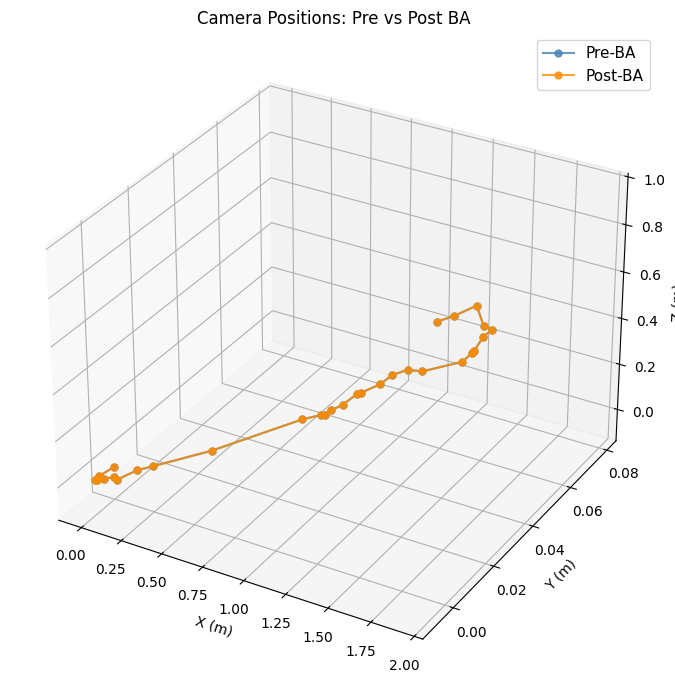

Camera displacement — mean: 0.0000 m  max: 0.0000 m


In [5]:
def _camera_centers(extrinsics: np.ndarray) -> np.ndarray:
    """Return world-space camera centers from (N, 4, 4) world-to-camera extrinsics."""
    R = extrinsics[:, :3, :3]  # (N, 3, 3) rotation
    t = extrinsics[:, :3, 3]  # (N, 3) translation
    # Camera center in world = -R.T @ t (inverse of world-to-camera translation)
    return np.einsum("nij,nj->ni", R.transpose(0, 2, 1), -t)


# Extract per-camera world positions before and after BA
centers_pre = _camera_centers(extrinsics_pre)
centers_post = _camera_centers(refined.extrinsics)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Trajectory arcs — connect consecutive cameras with a line
ax.plot(*centers_pre.T, "o-", color="steelblue", label="Pre-BA", alpha=0.8, markersize=5)
ax.plot(*centers_post.T, "o-", color="darkorange", label="Post-BA", alpha=0.8, markersize=5)

# Per-camera displacement connectors — show how much each camera moved
for pre, post in zip(centers_pre, centers_post):
    ax.plot(
        [pre[0], post[0]],
        [pre[1], post[1]],
        [pre[2], post[2]],
        color="gray",
        alpha=0.35,
        linewidth=0.8,
        linestyle="--",
    )

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.legend(fontsize=11)
ax.set_title("Camera Positions: Pre vs Post BA")
plt.tight_layout()
plt.show()

# Summary: mean and max displacement per camera
deltas = np.linalg.norm(centers_post - centers_pre, axis=-1)
print(f"Camera displacement — mean: {deltas.mean():.4f} m  max: {deltas.max():.4f} m")

2026-07-19 14:55:52.719 ( 107.730s) [    77C3A0327740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


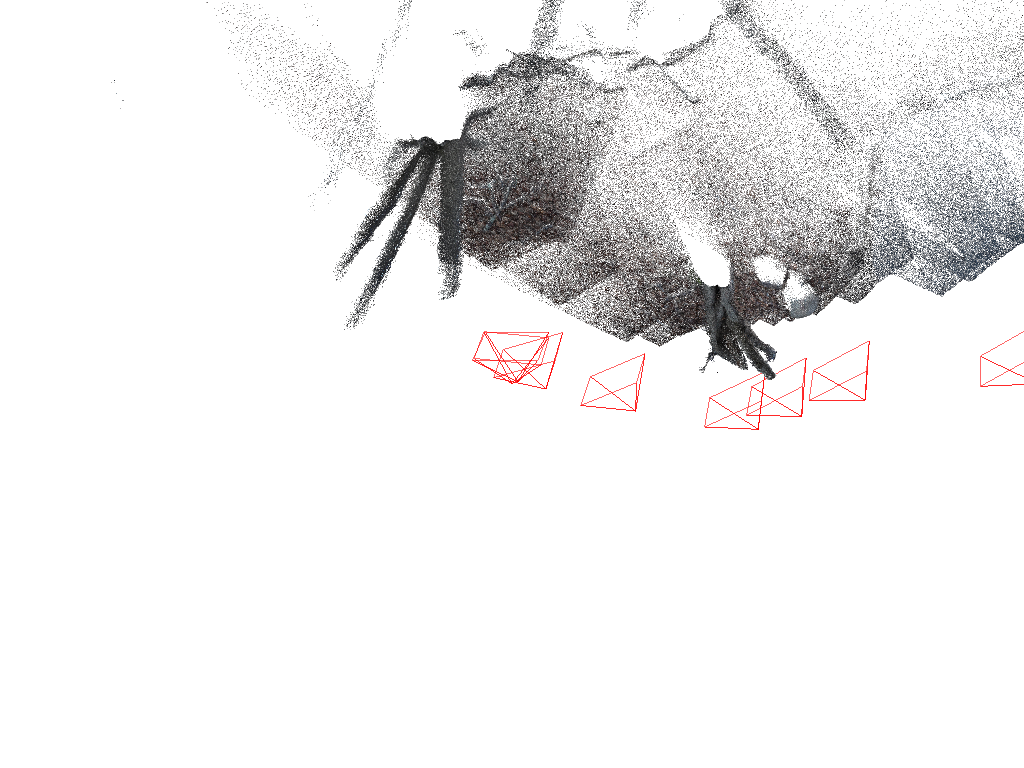

In [6]:
# Build PyVista PolyData with per-point RGB colours from the reprojected (post-BA) result
pcd = pointcloud_to_polydata(reprojected.points, RGB=reprojected.colors)

# Render post-BA pointcloud with post-BA camera frustums overlaid
visualize_splat(
    pcd,
    aligned_cameras=list(reprojected.extrinsics),
    mesh_kwargs={**PCD_KWARGS, "rgb": True},
    camera_kwargs=CAMERA_KWARGS,
    viz_kwargs=VIZ_KWARGS,
).show()

In [7]:
loss_hist = ba._last_loss_history

if not loss_hist:
    # capture_loss_history is enabled — an empty history means the optimizer never ran:
    # the reprojection filter admitted no frames (see the scene note above).
    print("Optimizer did not run — no admissible tracks on this small-baseline scene.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    steps = list(range(1, len(loss_hist) + 1))

    # Loss curve on log scale — LM losses can span several orders of magnitude
    ax.semilogy(steps, loss_hist, "o-", color="steelblue", markersize=5, linewidth=1.5)

    # Final-loss reference line
    ax.axhline(
        loss_hist[-1],
        color="gray",
        linestyle="--",
        alpha=0.6,
        label=f"Final: {loss_hist[-1]:.3e}",
    )

    ax.set_xlabel("LM Step")
    ax.set_ylabel("Loss (log scale)")
    ax.set_title("Bundle Adjustment — LM Loss Convergence")
    ax.legend(fontsize=11)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print improvement ratio
    print(
        f"Loss reduction: {loss_hist[0]:.3e} → {loss_hist[-1]:.3e}  "
        f"({loss_hist[0] / loss_hist[-1]:.1f}× improvement)"
    )

Optimizer did not run — no admissible tracks on this small-baseline scene.


## Where to go next

- **Benchmarks across baseline/BA/LC** — `evals/eval_gt.py` (compute) + `docs/pointcloud/eval_7scenes_gt.ipynb` (viz)
- **Loop closure path** — `collab_splats.pointcloud.LoopClosure`
- **Tunable knobs** — `BundleAdjustmentConfig` (`max_reproj_error`, `lm_steps`, `shared_camera`, `min_inliers_per_frame`, `device`)
- **Source** — `collab_splats/geometry/bundle_adjustment.py` (BundleAdjustment class, BundleAdjustmentConfig), `collab_splats/pointcloud/feedforward/base.py` (BaseFeedforwardCreator.run, .reproject)